In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv("../data/raw/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df["income_cat"] = pd.cut(
    df["median_income"],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, test_idx in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_idx].drop("income_cat", axis=1)
    strat_test_set = df.loc[test_idx].drop("income_cat", axis=1)

In [4]:
# Training Set
housing = strat_train_set.copy()
housing_labels = housing["median_house_value"].copy()
housing = housing.drop("median_house_value", axis=1)

# Testing Set
test = strat_test_set.copy()
test_labels = test["median_house_value"].copy()
test = test.drop("median_house_value", axis=1)

In [5]:
housing_num = housing.select_dtypes(
    include=[np.number]
).columns.tolist()
housing_cat = ["ocean_proximity"]

print("Numerical features:")
print(housing_num)

print("\nCategorical features:")
print(housing_cat)

Numerical features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Categorical features:
['ocean_proximity']


In [6]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, housing_num),
    ("cat", cat_pipeline, housing_cat)
])

housing_processed = full_pipeline.fit_transform(housing)
test_processed = full_pipeline.transform(test)

print("Training shape:", housing_processed.shape)
print("Test shape:", test_processed.shape)

Training shape: (16512, 13)
Test shape: (4128, 13)


In [7]:
final_model = RandomForestRegressor(
    n_estimators=50,
    min_samples_split=5,
    max_features=8,
    max_depth=20,
    random_state=42
)
final_model.fit(housing_processed, housing_labels)

RandomForestRegressor(max_depth=20, max_features=8, min_samples_split=5,
                      n_estimators=50, random_state=42)

In [8]:
test_predictions = final_model.predict(test_processed)

In [9]:
final_rmse = root_mean_squared_error(
    test_labels,
    test_predictions
)

final_mae = mean_absolute_error(
    test_labels,
    test_predictions
)

final_r2 = r2_score(
    test_labels,
    test_predictions
)

print("Final Test RMSE:", final_rmse)
print("Final Test MAE:", final_mae)
print("Final Test R²:", final_r2)

Final Test RMSE: 46994.542046856484
Final Test MAE: 31295.903981081137
Final Test R²: 0.8305484892773352


## Prediction error analysis

In [10]:
errors = test_labels - test_predictions

error_analysis = pd.DataFrame({
    "Actual": test_labels.values,
    "Predicted": test_predictions,
    "Error": errors.values,
    "Absolute_Error": np.abs(errors.values)
})

error_analysis.head()

,Actual,Predicted,Error,Absolute_Error
0,500001.0,490191.078381,9809.921619,9809.921619
1,162500.0,223385.442152,-60885.442152,60885.442152
2,204600.0,203715.296211,884.703789,884.703789
3,159700.0,173799.912203,-14099.912203,14099.912203
4,184000.0,212938.954762,-28938.954762,28938.954762


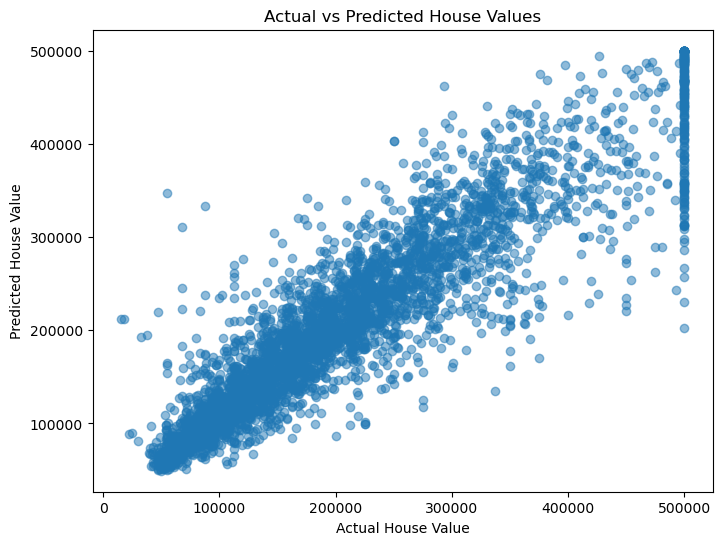

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    test_labels,
    test_predictions,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

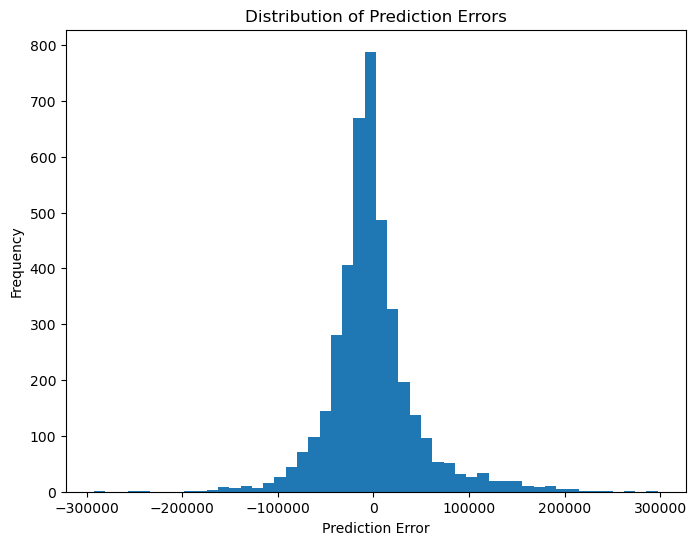

In [12]:
plt.figure(figsize=(8, 6))

plt.hist(errors, bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

In [13]:
joblib.dump(
    final_model,
    "../models/final_model.joblib"
)

joblib.dump(
    full_pipeline,
    "../models/preprocessing_pipeline.joblib"
)

['../models/preprocessing_pipeline.joblib']